In [ ]:
#Code with the topic: Decision Tree Classification

#Objective:

# The objective of this project is to build a Decision Tree Classification
# model capable of predicting whether a customer will purchase a product
# based on their age, salary, and number of visits.

#Technologies used:

#Pandas 
#Matplotlib 
#Python 
#Scikit Learn 
#Jupyter notebook 
#Visual Studio code 

#Methodology:

#1 Load and explore the dataset using Pandas.
#2 Analyze the dataset structure and descriptive statistics.
#3 Select the input features (Age, Salary, and Visits) and the target variable (Buy).
#4 Split the dataset into training and testing sets.
#5 Build and train a Decision Tree Classification model using the Entropy criterion.
#6 Evaluate the model using accuracy and a classification report.
#7 Use the trained model to predict the purchase decision of a new customer.
#8 Visualize the trained Decision Tree using Matplotlib and Scikit-learn.


In [26]:
#We import the libraries

import pandas as pd 
import matplotlib.pyplot  as plt 

from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report



In [27]:
#Load the dataset 

data = pd.read_csv("Decision_Tree_Classification.csv")

In [28]:
#Visualization

data.head()

,Age,Salary,Visits,Buy
0,22,18000,2,No
1,25,22000,3,No
2,28,25000,4,No
3,30,30000,5,Yes
4,32,35000,6,Yes


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Age     36 non-null     int64 
 1   Salary  36 non-null     int64 
 2   Visits  36 non-null     int64 
 3   Buy     36 non-null     object
dtypes: int64(3), object(1)
memory usage: 1.3+ KB


In [30]:
data.describe()

,Age,Salary,Visits
count,36.000000,36.000000,36.000000
mean,39.916667,43972.222222,4.777778
std,11.723907,18035.656923,1.972831
min,21.000000,15000.000000,1.000000
25%,29.750000,29500.000000,3.000000
50%,40.500000,45500.000000,5.000000
75%,49.500000,55750.000000,6.000000
max,59.000000,80000.000000,8.000000


In [31]:
#Prepare the data 

#Features

X = data[["Age","Salary","Visits"]]

#Target

Y = data[["Buy"]]

In [32]:
#Split the dataset 

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2, random_state=42)

In [33]:
print("\nTraining samples:", len(x_train))
print("Testing samples:", len(x_test))


Training samples: 28
Testing samples: 8


In [34]:
#Create the Decision Tree Model 

model = DecisionTreeClassifier(criterion="entropy",max_depth=4,random_state=42)

In [35]:
#Train the model 

model.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [36]:
#Make predictions 

y_pred = model.predict(x_test)

In [37]:
#Evaluate the model 

accuracy = accuracy_score(y_test, y_pred)


print("\nModel Accuracy:")
print(f"{accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Model Accuracy:
100.00%

Classification Report:


              precision    recall  f1-score   support

          No       1.00      1.00      1.00         3
         Yes       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [38]:
#Predict a new customer 

new_customer = pd.DataFrame({
    "Age":[35],
    "Salary":[40000],
    "Visits": [6]
})

prediction = model.predict(new_customer)

print("\nNew Customer:")
print(new_customer)

print("\nPrediction:")
print(prediction[0])


New Customer:
   Age  Salary  Visits
0   35   40000       6

Prediction:
Yes


[Text(0.5, 0.75, 'Salary <= 29000.0\nentropy = 0.75\nsamples = 28\nvalue = [6, 22]\nclass = Yes'),
 Text(0.25, 0.25, 'entropy = 0.0\nsamples = 6\nvalue = [6, 0]\nclass = No'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'entropy = 0.0\nsamples = 22\nvalue = [0, 22]\nclass = Yes'),
 Text(0.625, 0.5, '  False')]

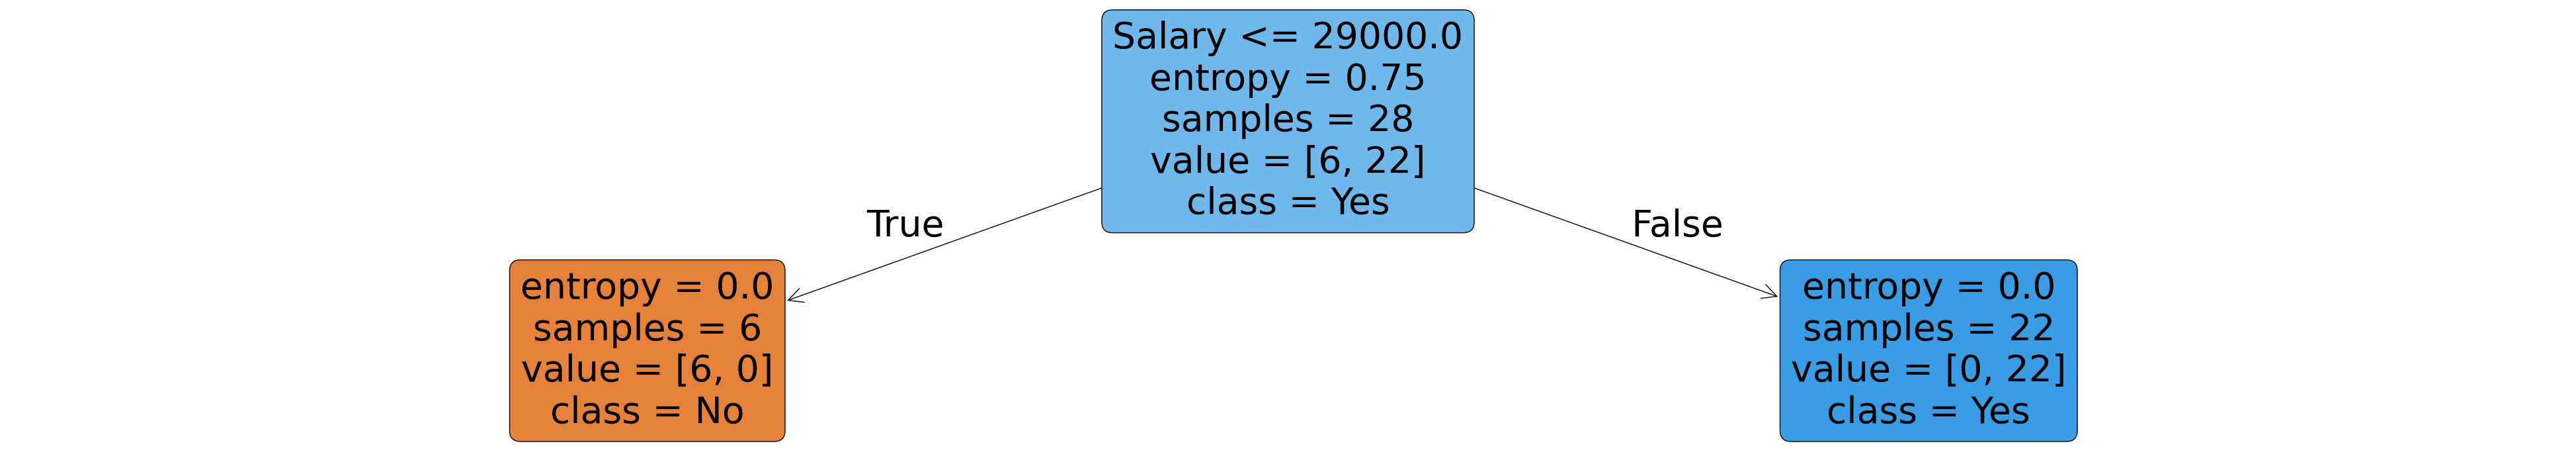

In [42]:
#Display the decision Tree

plt.figure(figsize=(50,9))

plot_tree(
    model,
    feature_names=["Age","Salary","Visits"],
    class_names=model.classes_,
    filled=True,
    rounded=True
)

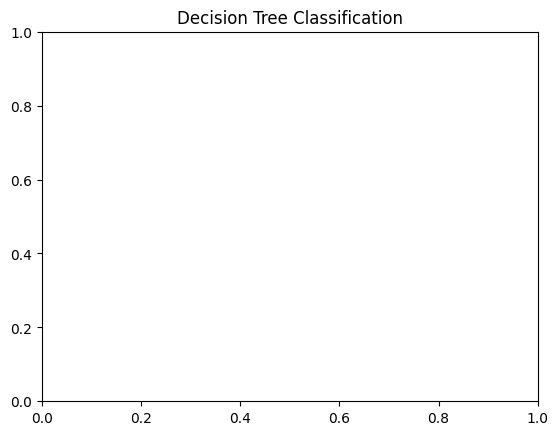

In [40]:

plt.title("Decision Tree Classification")
plt.show()